In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir())

['.config', 'drive', 'sample_data']


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/card_transdata.csv")

print("Shape:", df.shape)
df.head()

Shape: (1000000, 8)


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [ ]:
print("\nFraud Distribution:\n", df['fraud'].value_counts())
print("\nMissing Values:\n", df.isnull().sum())


Fraud Distribution:
 fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

Missing Values:
 distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64


In [ ]:
df = df.drop_duplicates()

cols = ['repeat_retailer','used_pin_number','online_order','fraud']

df[cols] = df[cols].replace([np.inf, -np.inf], np.nan).fillna(0).astype(int)

print("After cleaning:", df.shape)

After cleaning: (1000000, 8)


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('fraud', axis=1)
y = df['fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# IMPORTANT FIX
X_train = X_train.copy()
X_test = X_test.copy()

In [ ]:
log_columns = [
    'distance_from_home',
    'distance_from_last_transaction',
    'ratio_to_median_purchase_price'
]

for col in log_columns:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

    median_val = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

    X_train[col] = np.log1p(X_train[col].clip(lower=0))
    X_test[col] = np.log1p(X_test[col].clip(lower=0))

In [ ]:
clip_values = {}

for col in log_columns:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)

    clip_values[col] = (lower, upper)

    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

In [ ]:

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weight = {0: weights[0], 1: weights[1]}
print("Class Weights:", class_weight)

Class Weights: {0: np.float64(0.5478866641646509), 1: np.float64(5.720660164182947)}


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight
)

Epoch 1/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - loss: 0.1094 - precision: 0.6389 - recall: 0.9692 - val_loss: 0.0320 - val_precision: 0.8720 - val_recall: 0.9949
Epoch 2/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.0451 - precision: 0.8414 - recall: 0.9868 - val_loss: 0.0303 - val_precision: 0.8851 - val_recall: 0.9977
Epoch 3/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.0330 - precision: 0.8864 - recall: 0.9901 - val_loss: 0.0217 - val_precision: 0.9102 - val_recall: 0.9978
Epoch 4/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - loss: 0.0276 - precision: 0.9018 - recall: 0.9921 - val_loss: 0.0130 - val_precision: 0.9432 - val_recall: 0.9973
Epoch 5/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - loss: 0.0256 - precision: 0.9077 - recall: 0.9930 - val_loss: 0.0167 - val_precision: 0.9286 - val_recall: 0.9983
Epoch 6/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 0.0245 - precision: 0.9108 - recall: 0.9932 - val_loss: 0.0241 - val_p

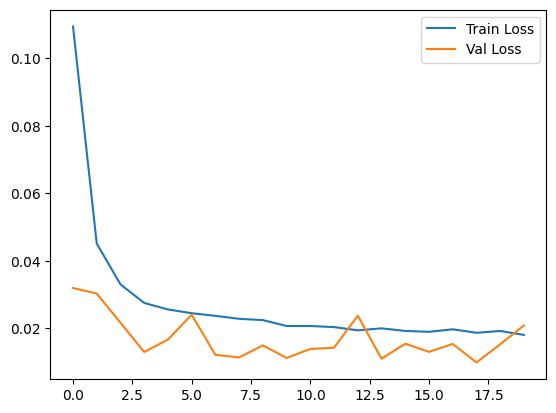

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

In [ ]:
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.7).astype(int)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.996825

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    182519
           1       0.97      1.00      0.98     17481

    accuracy                           1.00    200000
   macro avg       0.98      1.00      0.99    200000
weighted avg       1.00      1.00      1.00    200000


Confusion Matrix:

[[181919    600]
 [    35  17446]]


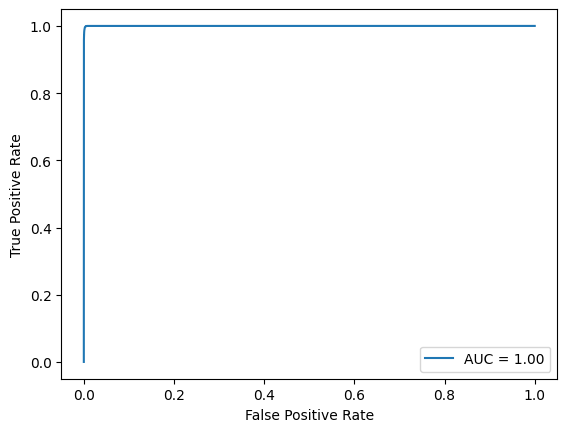

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
import pickle

pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(log_columns, open("log_columns.pkl", "wb"))
pickle.dump(clip_values, open("clip_values.pkl", "wb"))